In [ ]:
# Celda de preparación para asegurar compatibilidad
try:
    import pandas as pd             # Analizar y limpizar datos en forma de tablas
    import numpy as np              # Crear y manejar matrices y arreglos numéricos gigantes
    import matplotlib.pylab as plt  # Crea gráficos 2D
    import seaborn as sns           # Construido osbre Matplotlib para hacer gráficos más modernos
    print("¡Librerías listas y verificadas!")

except ImportError:
    print("Instalando librerías faltantes...")
    %pip install pandas matplotlib seaborn numpy

plt.style.use('bmh')

#### Dataset sobre sistemas de bicicletas compartidas en Chicago en el año de 2016.

#### Diccionario:
- trip_id: Id del viaje.

- starttime: Fecha y hora de inicio del viaje.

- stoptime: Fecha y hora de finalización del viaje.

- bikeid: ID de la bicicleta utilizada.

- tripduration: Duración (en segundos) del viaje.

- from_station_id: ID de la estación donde inició el viaje.

- from_station_name: Nombre de la estación donde inició el viaje.

- to_station_id: ID de la estación donde termino el viaje.

- to_station_name: Nombre de la estación donde termino el viaje.

- usertype: Tipo de usuario registrado para usar la bicicleta (Subscriptor y Cliente).

- gender: Género del usuario.

- birthyear: Año de nacimiento del usuario.

# Importación de dataset y librerias

In [66]:
df = pd.read_csv('Chicago-Divvy-2016.csv')
df

,trip_id,starttime,stoptime,bikeid,tripduration,from_station_id,from_station_name,to_station_id,to_station_name,usertype,gender,birthyear
0,9080545,3/31/2016 23:30,3/31/2016 23:46,2295,926,156,Clark St & Wellington Ave,166,Ashland Ave & Wrightwood Ave,Subscriber,Male,1990.0
1,9080521,3/31/2016 22:59,3/31/2016 23:02,3439,198,259,California Ave & Francis Pl,276,California Ave & North Ave,Subscriber,Male,1974.0
2,9080479,3/31/2016 22:24,3/31/2016 22:26,4337,124,344,Ravenswood Ave & Lawrence Ave,242,Damen Ave & Leland Ave,Subscriber,Female,1992.0
3,9080475,3/31/2016 22:22,3/31/2016 22:41,3760,1181,318,Southport Ave & Irving Park Rd,458,Broadway & Thorndale Ave,Subscriber,Female,1979.0
4,9080443,3/31/2016 22:08,3/31/2016 22:19,1270,656,345,Lake Park Ave & 56th St,426,Ellis Ave & 60th St,Subscriber,Female,1997.0
...,...,...,...,...,...,...,...,...,...,...,...,...
72126,12150369,10/01/2016 01:40,10/01/2016 01:43,1651,233,117,Wilton Ave & Belmont Ave,114,Sheffield Ave & Waveland Ave,Subscriber,Male,1971.0
72127,12150340,10/01/2016 01:21,10/01/2016 01:29,4803,472,123,California Ave & Milwaukee Ave,503,Drake Ave & Fullerton Ave,Subscriber,Female,1991.0
72128,12150249,10/01/2016 00:35,10/01/2016 00:53,3906,1069,90,Millennium Park,197,Michigan Ave & Madison St,Customer,NaN,NaN
72129,12150216,10/01/2016 00:19,10/01/2016 00:44,5882,1492,300,Broadway & Barry Ave,300,Broadway & Barry Ave,Subscriber,Male,1993.0


# PASO 1: ESTRUCTURA Y RESUMEN
- #### Estructura General (filas, columnas, tipos de variables) 
- #### Diferenciar Variables (numéricas, categóricas y temporales)
- #### Medidas de Resumen (media, mediana, desviación estándar)
- #### Detectar valores nulos, duplicados o inconsistencias iniciales
- #### Observar rangos y escalas para futuras transformaciones

In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72131 entries, 0 to 72130
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   trip_id            72131 non-null  int64  
 1   starttime          72131 non-null  str    
 2   stoptime           72131 non-null  str    
 3   bikeid             72131 non-null  int64  
 4   tripduration       72131 non-null  int64  
 5   from_station_id    72131 non-null  int64  
 6   from_station_name  72131 non-null  str    
 7   to_station_id      72131 non-null  int64  
 8   to_station_name    72131 non-null  str    
 9   usertype           72131 non-null  str    
 10  gender             54977 non-null  str    
 11  birthyear          54986 non-null  float64
dtypes: float64(1), int64(5), str(6)
memory usage: 6.6 MB


In [68]:
print("La dimensión del dataframe es el siguiente:", df.shape)

La dimensión del dataframe es el siguiente: (72131, 12)


- Las columnas *gender* y *birthyear* tienen menos registros que la cantidad total (72131).

- La columna de género (_gender_) tiene 54977 registros.

- La columna de la fecha del cumpleaños (_birthyear_) del usuario tiene 54986 registros.

Faltan más de 17000 datos en ambas columnas.

Una posibilidad es que los usuarios de tipo _Customer_ no están obligados a registrar su género ni su año de nacimiento.

- La columna *birthyear* es de tipo flotante, al investigar un poco al respecto encuentro que Pandas convierte la columna a tipo flotante debido a que solo acepta valores nulos en una columna de tipo *float64*.

Esta busqueda la hice debido al notar que las primeras y últimas filas (en esta ocasión la fila 72128) de la tabla, noté que había un valor nulo (NaN), además los años eran decimales.

Las columnas _starttime_ y _stoptime_ son de tipo _str_, serán convertidos a tipo datetime para poder analizar el dataset de forma apropiada.

## Nombre de cada columna

In [69]:
df.columns

Index(['trip_id', 'starttime', 'stoptime', 'bikeid', 'tripduration',
       'from_station_id', 'from_station_name', 'to_station_id',
       'to_station_name', 'usertype', 'gender', 'birthyear'],
      dtype='str')

## Tipos de Dato en cada Columna

In [70]:
df.dtypes

trip_id                int64
starttime                str
stoptime                 str
bikeid                 int64
tripduration           int64
from_station_id        int64
from_station_name        str
to_station_id          int64
to_station_name          str
usertype                 str
gender                   str
birthyear            float64
dtype: object

## Resumen Estadístico Descriptivo - Numéricas

In [71]:
df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
trip_id,72131.0,1.080197e+07,1.261951e+06,8547222.0,9730023.0,10822726.0,11895101.5,12979092.0
bikeid,72131.0,2.966389e+03,1.674491e+03,1.0,1523.0,3026.0,4381.0,5919.0
tripduration,72131.0,9.938178e+02,1.970898e+03,60.0,408.0,701.0,1174.0,86365.0
from_station_id,72131.0,1.781974e+02,1.272826e+02,2.0,74.0,157.0,268.0,620.0
to_station_id,72131.0,1.773513e+02,1.275155e+02,2.0,73.0,156.0,268.0,620.0
birthyear,54986.0,1.980424e+03,1.082339e+01,1899.0,1975.0,1984.0,1989.0,2000.0


_tripduration_ -> Valor máximo es '86365.0' segundos, pasado a minutos son 1439.42, y pasado a horas son 23.9 horas, puede haber un error del usuario donde olvido devolver a tiempo la bicicleta o fue recuperado y devuelto ese tiempo después.

_birthyear_ -> Valor mínimo es '1899.0', puede ser un error de registro.

## Resumen Estadístico Descriptivo - Categóricas

In [72]:
df[['usertype','gender']].describe()

,usertype,gender
count,72131,54977
unique,2,2
top,Subscriber,Male
freq,54982,41194


- En la columna del tipo de usuario hay una mayor frecuencia de tipo _Subscriber_.
- En la columna de género hay mayor frecuencia de hombres que viajaron.

El siguiente código comprueba si los datos faltantes de _gender_ y _birthyear_ dependen del tipo de usuario 'Customer'.

In [73]:
df.groupby('usertype')[['gender', 'birthyear']].count()

,gender,birthyear
usertype,,
Customer,4,4
Subscriber,54973,54982


_Customer_ muestra que solo 4 usuarios si llenaron los datos de su año de cumpleaños y su género.

En cambio en la columna _Subscriber_ hay una pequeña diferencia en la cantidad que llenaron los datos de su año de cumpleaños y su género, redondeando unos 55 mil aprox.

# Duplicados

In [74]:
# Filas duplicadas
print('Filas duplicadas: ', df.duplicated().sum())

Filas duplicadas:  0


In [75]:
# Duplicados de Clave:
df[df.duplicated(subset=['trip_id'], keep=False)]

,trip_id,starttime,stoptime,bikeid,tripduration,from_station_id,from_station_name,to_station_id,to_station_name,usertype,gender,birthyear


Puede haber un duplicado u error donde:

- Una bici empieza un viaje antes de que termine el anterior?
(Requiere que starttime y stoptime sean de tipo datetime)

El dataframe se encuenta libre de valores NaN como duplicados, pero falta examinar que no haya una inconsistencia lógica (_starttime_, _stoptime_ y _bikeid_).

# PASO 2: ANALIZAR DISTRIBUCIONES
- #### Examinar la forma de la distribución: normal, sesgada, bimodal, etc.
- #### Calcular medidas de dispersión (rango, varianza, desviación estándar).
- #### Identificar valores extremos (outliers) y su posible impacto.
- #### Comparar distribuciones entre subgrupos o categorías.
- #### Detectar la necesidad de transformaciones (log, estandarización).


Obtener datos estadisticos de la fecha

In [76]:
df2 = df.copy()
df2['starttime'] = pd.to_datetime(df2['starttime'])
df2['stoptime'] = pd.to_datetime(df2['stoptime'])

df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 72131 entries, 0 to 72130
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   trip_id            72131 non-null  int64         
 1   starttime          72131 non-null  datetime64[us]
 2   stoptime           72131 non-null  datetime64[us]
 3   bikeid             72131 non-null  int64         
 4   tripduration       72131 non-null  int64         
 5   from_station_id    72131 non-null  int64         
 6   from_station_name  72131 non-null  str           
 7   to_station_id      72131 non-null  int64         
 8   to_station_name    72131 non-null  str           
 9   usertype           72131 non-null  str           
 10  gender             54977 non-null  str           
 11  birthyear          54986 non-null  float64       
dtypes: datetime64[us](2), float64(1), int64(5), str(4)
memory usage: 6.6 MB


Nueva variable para comprobar si hay una Inconsistencia Lógica

In [77]:
df_ordenado = df2.sort_values(by=['bikeid', 'starttime'])

bici_duplicada = (df_ordenado['bikeid'] == df_ordenado['bikeid'].shift(1)) & \
                  (df_ordenado['starttime'] < df_ordenado['stoptime'].shift(1))

df_ordenado[bici_duplicada]

,trip_id,starttime,stoptime,bikeid,tripduration,from_station_id,from_station_name,to_station_id,to_station_name,usertype,gender,birthyear


No fue encontrado ningun registro con una inconsistencia lógica.

Resumen Estadístico Descriptivo sobre las fechas

In [78]:
df = df2.copy()
df.describe(include='datetime').T

,count,mean,min,25%,50%,75%,max
starttime,72131,2016-07-17 02:14:32.902635,2016-01-01 00:26:00,2016-05-26 10:51:00,2016-07-19 19:54:00,2016-09-15 15:21:30,2016-12-31 20:49:00
stoptime,72131,2016-07-17 02:31:06.516477,2016-01-01 00:51:00,2016-05-26 11:02:00,2016-07-19 20:10:00,2016-09-15 15:45:30,2016-12-31 20:53:00


El dataset cubre exactamente un año completo de operación (todo el 2016) y se encuentran el total de registros en ambas columnas de fecha y hora.

Comprobamos si hay valores NaN

In [79]:
df.isna().sum()

trip_id                  0
starttime                0
stoptime                 0
bikeid                   0
tripduration             0
from_station_id          0
from_station_name        0
to_station_id            0
to_station_name          0
usertype                 0
gender               17154
birthyear            17145
dtype: int64

### Histograma con la duración de los viajes

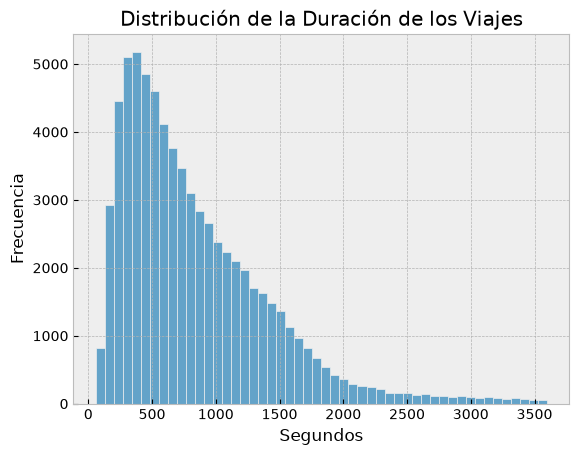

In [80]:
plt.figure()

# Los viajes serán filtrados a 1 hora (3600s) para que el gráfico sea más legible debido al outlier de 24hs.
sns.histplot(df[df['tripduration'] < 3600]['tripduration'], bins=50)

plt.title('Distribución de la Duración de los Viajes')
plt.xlabel('Segundos')
plt.ylabel('Frecuencia')
plt.show()

Sesgado fuertemente a la derecha, y esto es normal porque la mayoría de los viajes son cortos (una mediana de 701 segundos)

### Boxplot por los outliers _tripduration_ y _birthyear_

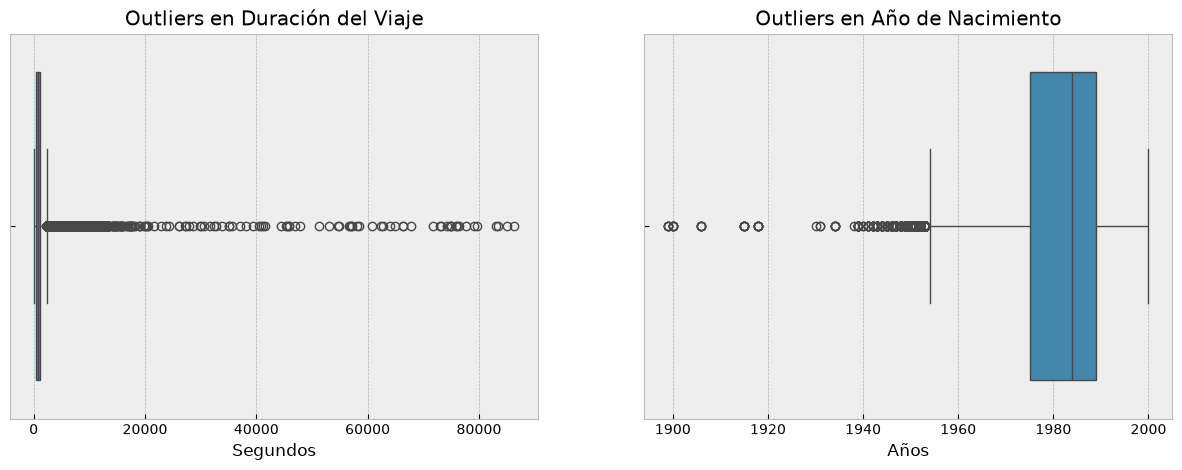

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5)) # Una fila, dos columnas

# Duración del viaje
sns.boxplot(ax=axes[0], x=df['tripduration'])
axes[0].set_title('Outliers en Duración del Viaje')
axes[0].set_xlabel('Segundos')

# Año de Nacimiento
sns.boxplot(ax=axes[1], x=df['birthyear'])
axes[1].set_title('Outliers en Año de Nacimiento')
axes[1].set_xlabel('Años')

plt.show()

En el gráfico de la izquierda se puede ver como hay registros respecto a la duración del viaje de 5 (20000s), 10 (36000s) o hasta 24 (86400s) horas. Estos pueden ser causados por diversos mótivos, sea bici robada, error del sistema, el usuario no anclo bien la bicicleta en la estación de destino, etc.

En el gráfico de la derecha se puede ver mejor la caja azul, pero se encuentran registros de año de nacimiento de usuarios mayores de 100 años lo cuál son improbables, pudo haber sido error de registro o datos falsos.

### Gráfico de Barras para la distribución de la Variables Categóricas

El siguiente gráfico representa exclusivamente a los _Subscriber_ debido a que está sesgado, ya que los 17000 _Customer_ no registraron su género (solo 4 lo hicieron).

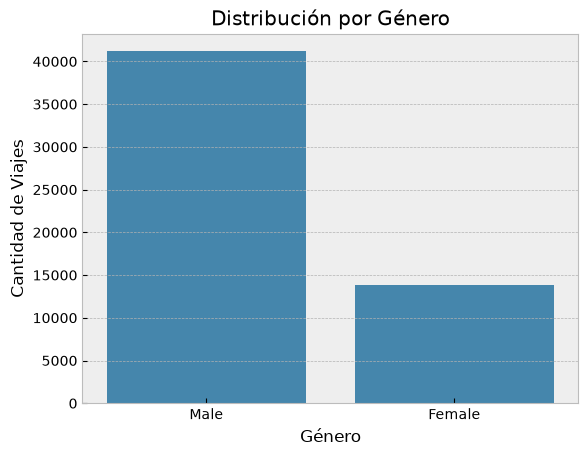

In [82]:
plt.figure()
sns.countplot(x='gender', data=df)
plt.title('Distribución por Género')
plt.xlabel('Género')
plt.ylabel('Cantidad de Viajes')
plt.show()

Hay una mayoría del género masculino (supera los 40000 viajes) frente al femenino (ronda los 13000).

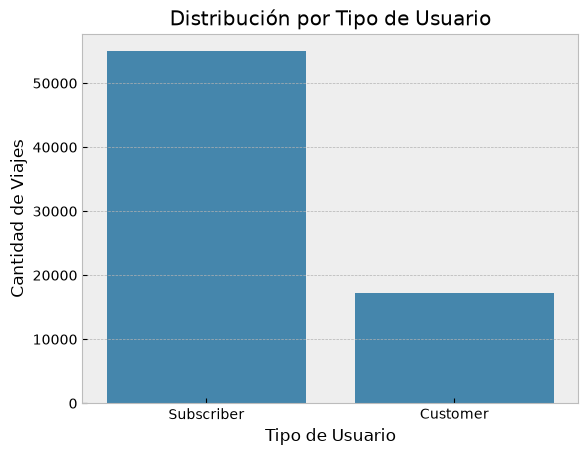

In [83]:
plt.figure()
sns.countplot(x='usertype', data=df)
plt.title('Distribución por Tipo de Usuario')
plt.xlabel('Tipo de Usuario')
plt.ylabel('Cantidad de Viajes')
plt.show()

Los suscriptores representan la gran mayoría de viajes (más de 50000 viajes), mientras que los clientes son la minoría (aproximadamente 17000).

### Boxplot para comparar _Customer_ y _Subscriber_

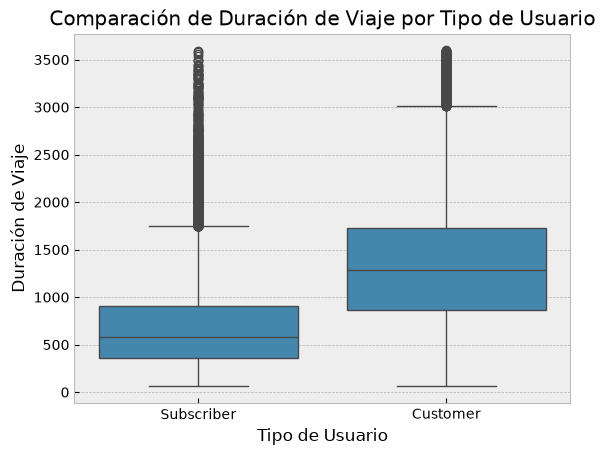

In [121]:
plt.figure()
# Reducido a 1 hora para que las cajas seán más legibles
sns.boxplot(x='usertype', y='tripduration', data=df[df['tripduration'] < 3600])
plt.title('Comparación de Duración de Viaje por Tipo de Usuario')
plt.xlabel('Tipo de Usuario')
plt.ylabel('Duración de Viaje')
plt.show()

#### Mediana
El gráfico de tipo boxplot indica que un _cliente_ suele hacer viajes que duran el doble de tiempo de 10 minutos (600s) que los viajes de un _suscriptor_ (más de 20 minutos).
#### Dispersión
- La caja de _Subscriber_ es predecible, inician y terminar en un rango de tiempo similar y corto.
- La caja de _Customer_ tiene alta variabilidad, algunos usan la bici unos 10 minutos, pero otros los usan hasta 30, 40 o 50 minutos.
#### Outliers
- Para un _Subscriber_, un viaje de más de 29 minutos (1750s), es considerado un valor atípico para su grupo.
- Para un _Customer_ casi no tiene valores extremos ya que su "bigote" llega cerca del limite de los 3500 segundos (58.3 minutos), es un comportamiento normal que haga un viaje de casi una hora.

# PASO 3: Examinar Relaciones
- #### Analizar relaciones bivariadas o multivariadas (numéricas y categóricas).
- #### Detectar correlaciones lineales y no lineales.
- #### Identificar grupos, clusters o tendencias en los datos.
- #### Formular hipótesis: “¿Qué variable parece influir sobre cuál?”
- #### Preparar el terreno para la selección de variables o modelos posteriores.


## Edad vs Duración

### Scatter Plot para comparar _birthyear_ y _tripduration_

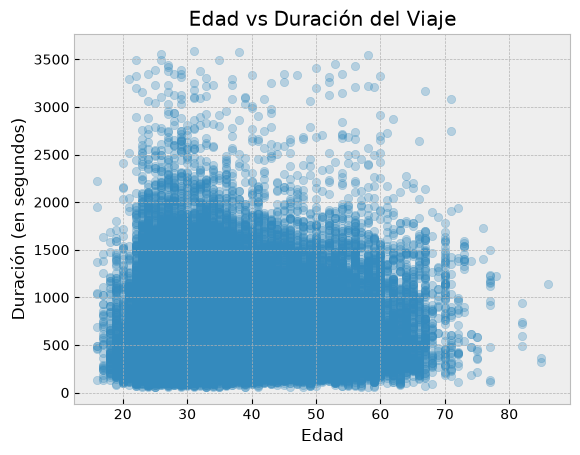

In [123]:
df_limpio = df[(df['tripduration'] < 3600) & (df['birthyear'] > 1920)]
edad = 2016 - df_limpio['birthyear']

plt.figure()
plt.scatter(edad, df_limpio['tripduration'], alpha=0.3)
plt.title('Edad vs Duración del Viaje')
plt.xlabel('Edad')
plt.ylabel('Duración (en segundos)')
plt.show()

Se observa que no tiene una correlación lineal fuerte, quiere decir que los cambios de una variable no tiene un impacto directo o predecible sobre la otra.

El volumen mayoritario de personas es entre 22 y 45 años con trayectos menores a 28 minutos (1700s), mientras que un patrón no lineal pero claro, es a partir de los 60 años.

### Matriz de Correlación para comparar _birthyear_ y _tripduration_

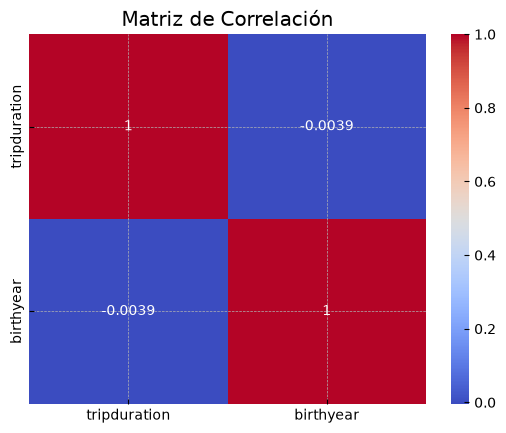

In [ ]:
columns = df[['tripduration', 'birthyear']]
corr_matrix = columns.corr() # Calcula la Matriz de Correlación

plt.figure()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

La diagonal principal con valor 1 indica que ambas variables (_tripduration_ y _birthyear_) suben exactamente en la misma proporción.

Como la diagonal de valor -0.0039 es casi idéntico a 0, quiere decir que la correlación lineal es nula, quiere decir que el año de nacimiento no tiene impacto ni poder predictivo sobre la duración de los viajes.

### Duración del viaje comparado con el año de nacimiento y el género

(Este tipo de comparación fue recuperado del video)

Se incorpora la variable categórica _gender_ al análisis de _birthyear_ y _tripduration_ usando scatterplot.

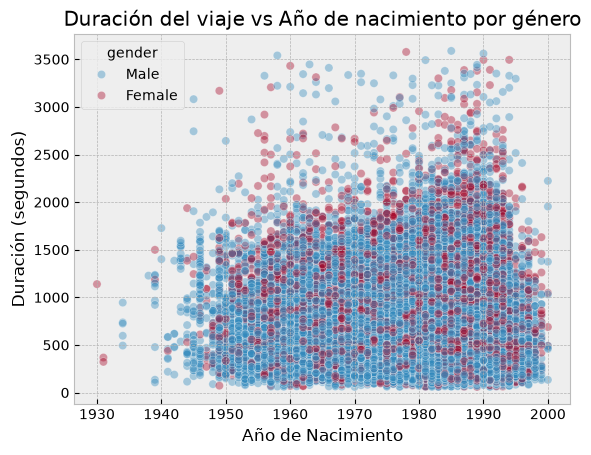

In [87]:
sns.scatterplot(
    data=df[(df['tripduration'] < 3600) & (df['birthyear'] > 1920)],
    x="birthyear",
    y="tripduration",
    hue="gender",
    alpha=0.4,
)

plt.title("Duración del viaje vs Año de nacimiento por género")
plt.xlabel("Año de Nacimiento")
plt.ylabel("Duración (segundos)")
plt.show()

No hay una franja exclusiva de hombres o mujeres, ambos se comportan de una manera similar en cuánto al tiempo que usan la bicicleta según la edad de los usuarios.

### Top 10 Estaciones de Inicio y Fin más Populares

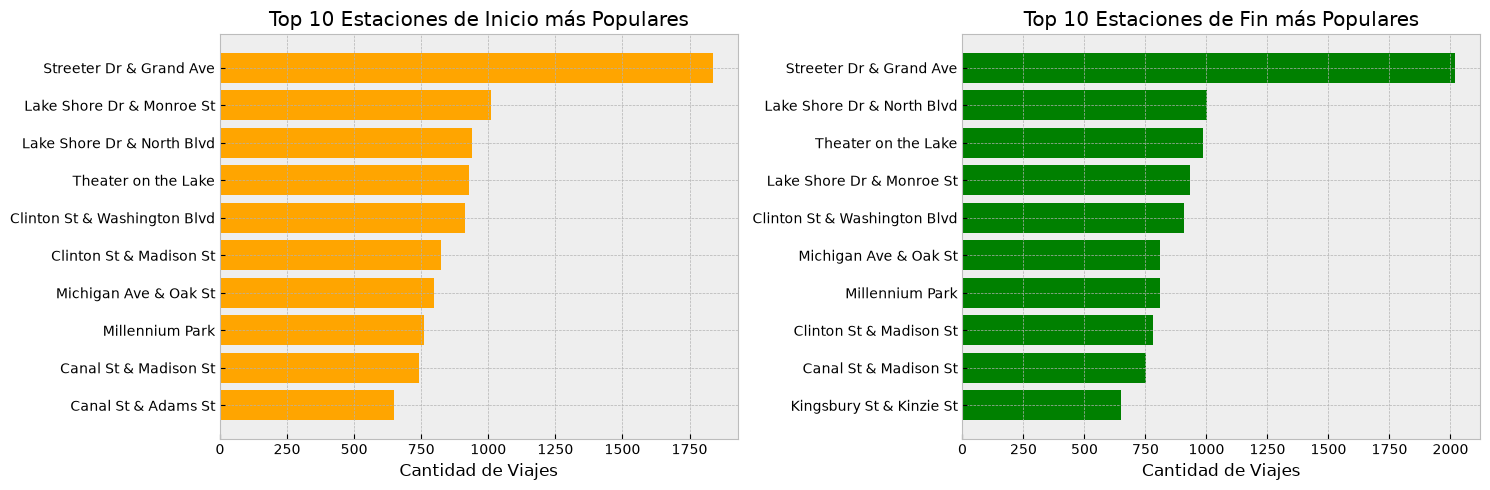

In [ ]:
top_inicio = df['from_station_name'].value_counts().head(10)
top_final = df['to_station_name'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(top_inicio.index, top_inicio.values, color='orange')
axes[0].set_title('Top 10 Estaciones de Inicio más Populares')
axes[0].set_xlabel('Cantidad de Viajes')
axes[0].invert_yaxis()  # Invierte el orden del eje Y

axes[1].barh(top_final.index, top_final.values, color='green')
axes[1].set_title('Top 10 Estaciones de Fin más Populares')
axes[1].set_xlabel('Cantidad de Viajes')
axes[1].invert_yaxis()

plt.tight_layout()  # Ajusta espacios y márgenes de subgráficos de manera automática
plt.show()


Los viajes que hay de Inicio a Fin de viaje son muy similares, quiere decir que las 10 estaciones más populares de Inicio coinciden casi en su totalidad con las de fin, lideradas por _Streeter Dr & Grande Ave_ y _Lake Shore Dr & Monroe St_

# PASO 4: Evaluar la Calidad de los Datos
- #### Detectar outliers extremos y evaluar su origen (error o fenómeno real).
- #### Revisar valores faltantes y decidir estrategias (imputar, eliminar, mantener).
- #### Identificar duplicados, inconsistencias o codificaciones erróneas.
- #### Evaluar la coherencia lógica entre variables (ej. fechas, totales, unidades).

### Mapa de Valores Faltantes

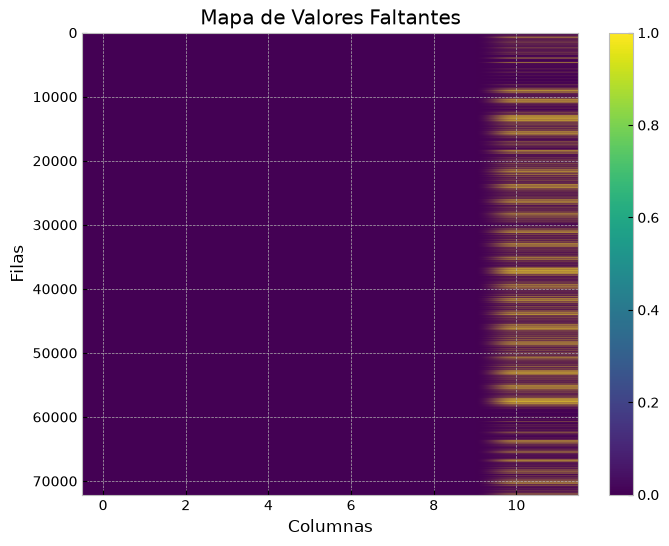

In [98]:
mask = df.isnull().astype(int).values

plt.figure(figsize=(8, 6))
plt.imshow(mask, aspect='auto')
plt.title('Mapa de Valores Faltantes')
plt.xlabel('Columnas')
plt.ylabel('Filas')

plt.colorbar()
plt.show()

Hay una alta integridad en los registros (columnas 0 a 9 completamente limpias), los datos faltantes se localizan en el número 10 (_gender_) y 11 (_birthyear_). Su dispersión es homogénea, no proviene de un fallo técnico, sino del comportamiento de los usuarios de tipo _Customer_.

### Conteo de Duplicados e Inconsistencias

In [125]:
# Duplicados absolutos
print('Duplicados (cantidad):', df.duplicated().sum())

# Inconsistencias lógicas en el año de nacimiento
incons_edad = df['birthyear'] < 1920
print('Inconsistencias en año de nacimiento (antes de 1920):', incons_edad.sum())

# Mostrar ejemplos si existes
if incons_edad.sum() > 0:
    print("\n Ejemplos de inconsistencias:")
    display(df[incons_edad].sort_values(by='birthyear', ascending=True).head(5))

Duplicados (cantidad): 0
Inconsistencias en año de nacimiento (antes de 1920): 28

 Ejemplos de inconsistencias:


,trip_id,starttime,stoptime,bikeid,tripduration,from_station_id,from_station_name,to_station_id,to_station_name,usertype,gender,birthyear
60599,12825489,2016-11-27 11:36:00,2016-11-27 11:43:00,5204,422,204,Prairie Ave & Garfield Blvd,423,University Ave & 57th St,Subscriber,Male,1899.0
60763,12814087,2016-11-23 20:51:00,2016-11-23 20:58:00,3817,434,259,California Ave & Francis Pl,158,Milwaukee Ave & Wabansia Ave,Subscriber,Male,1899.0
59632,12889086,2016-12-06 16:33:00,2016-12-06 16:44:00,3759,656,423,University Ave & 57th St,252,Greenwood Ave & 47th St,Subscriber,Male,1899.0
50864,10882652,2016-07-23 00:11:00,2016-07-23 00:16:00,302,306,290,Kedzie Ave & Palmer Ct,507,Humboldt Blvd & Armitage Ave,Subscriber,Male,1899.0
1087,9007080,2016-03-22 20:07:00,2016-03-22 20:25:00,722,1085,158,Milwaukee Ave & Wabansia Ave,343,Racine Ave & Wrightwood Ave,Subscriber,Male,1900.0


Se detectaron un total de 28 inconsistencias en la variable _birthyear_ con valores entre 1899 y 1918. Estos corresponden al tipo _Subscriber_, pueden ser relleno con datos falsos o valores por defecto del sistema.

# Conclusiones
- ### Outliers Extremos
Se detectó un outlier de 86365 segundos (24 horas) en _tripduration_. Se evalúa como un fenómero real, por robo (u olvido), mal colocado la bicicleta o uso extendido.

- ### Valores Faltantes
Existen valores NaN en las columnas _gender_ y _birthyear_. No se eliminarán porque tienen una coherencia lógica, debido a una supuesta decisión de los usuarios de tipo _Customer_.

- ### Duplicados
No hay ningún tipo de duplicado, es libre de redundancia.

- ### Coherencia Lógica
El análisis temporal sobre solapamientos de viajes para una misma bicicleta no fue encontrado ningún duplicado. Sin embargo, se detectaron inconsistencias en la columna _birthyear_ (< 1920), evaluados como errores de registro por parte del usuario.

## Preguntas que me surgieron durante el trabajo
- Debería estudiar más las librerias porque hay cosas que tal vez no entienda apropiadamente.
- A veces dependí de la IA para poder usar alguna libreria o me explicara si el bloque de código estaba bien y/o que significaba algunos resultados que no entendía del todo.
- ¿En todo este proceso (EDA), no se puede limpiar nada del dataset? (transformar, eliminar, seleccionar columnas)